In [10]:
from config import config
from src.data import load_data
import matplotlib.pyplot as plt

train_df, test_df = load_data(config)

print('Train:', train_df.shape)
print('Test:', test_df.shape)

assert train_df.shape == (1460, 81)
assert test_df.shape == (1459, 80)

assert 'SalePrice' in train_df.columns
assert 'SalePrice' not in test_df.columns

assert train_df['Id'].is_unique
assert test_df['Id'].is_unique

assert train_df['SalePrice'].notna().all()
assert (train_df['SalePrice'] > 0).all()

print(train_df['MasVnrType'].value_counts(dropna=False))

Train: (1460, 81)
Test: (1459, 80)
MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: count, dtype: int64


In [11]:
from src.data import load_data, split_train_holdout

train_df, _ = load_data(config)
train_cv_df, holdout_df = split_train_holdout(train_df, config)

eda_outlier_ids = {524, 1299}
train_cv_ids = set(train_cv_df['Id'])
holdout_ids = set(holdout_df['Id'])

# Проверяем, что заданные дома удалены из Train/CV и не попали в holdout.
assert eda_outlier_ids.isdisjoint(train_cv_ids)
assert eda_outlier_ids.isdisjoint(holdout_ids)

# Проверяем, что Train/CV и holdout не пересекаются.
assert train_cv_ids.isdisjoint(holdout_ids)

# Два удалённых дома объясняют разницу с размером исходного датасета.
assert len(train_cv_df) + len(holdout_df) + len(eda_outlier_ids) == len(train_df)

print('Full train:', train_df.shape)
print('Train/CV:', train_cv_df.shape)
print('Holdout:', holdout_df.shape)

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Full train: (1460, 81)
Train/CV: (1166, 81)
Holdout: (292, 81)


In [12]:
import pandas as pd
from config import config

# Старый вариант
train_old = pd.read_csv(config.paths.path_to_csv)

# Новый вариант
train_new = pd.read_csv(
    config.paths.path_to_csv,
    keep_default_na=False,
    na_values=['', 'NA'],
)

comparison = pd.concat(
    [
        train_old['MasVnrType'].value_counts(dropna=False),
        train_new['MasVnrType'].value_counts(dropna=False),
    ],
    axis=1,
    keys=['Старое чтение', 'Новое чтение'],
).fillna(0).astype(int)

comparison

,Старое чтение,Новое чтение
MasVnrType,,
NaN,872,8
BrkFace,445,445
Stone,128,128
BrkCmn,15,15
None,0,864


In [13]:
train_df.loc[train_df['MasVnrType'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
234,235,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500
529,530,20,RL,NaN,32668,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Alloca,200624
650,651,60,FV,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,205950
936,937,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,184900
973,974,20,FV,95.0,11639,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,New,Partial,182000
977,978,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,New,Partial,199900
1243,1244,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,New,Partial,465000
1278,1279,60,RL,75.0,9473,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,237000


In [14]:
import numpy as np

X = train_df.drop(columns=['Id', 'SalePrice']).copy()
y = np.log(train_df['SalePrice'])

X_test = test_df.drop(columns=['Id']).copy()

In [15]:
numerical_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

print('Числовых:', len(numerical_cols))
print('Категориальных:', len(categorical_cols))

print('Числовые признаки:')
print(numerical_cols)

Числовых: 35
Категориальных: 44
Числовые признаки:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


Проверка удаленных фичей

In [16]:
from src.train_functions import build_pipeline

features = train_cv_df.drop(columns=['SalePrice'])
labels_log = np.log(train_cv_df['SalePrice'])

pipe = build_pipeline(config)
pipe.fit(features, labels_log)

columns_transformer = pipe.named_steps['preprocessor'].named_steps['columns']
selected_features = set()

for name, _, columns in columns_transformer.transformers_:
    if name in ('numerical', 'categorical'):
        selected_features.update(columns)

dropped_features = set(config.preprocessing.drop_columns)
expected_features = set(features.columns) - {'Id'} - dropped_features

assert dropped_features.isdisjoint(selected_features)
assert selected_features == expected_features

print('Dropped features:', sorted(dropped_features))
print('Selected original features:', len(selected_features))

Dropped features: ['Alley', 'BedroomAbvGr', 'BldgType', 'BsmtUnfSF', 'Condition2', 'Exterior2nd', 'Fireplaces', 'GarageQual', 'GarageYrBlt', 'Heating', 'HouseStyle', 'LowQualFinSF', 'MasVnrArea', 'PoolQC', 'RoofMatl', 'Street', 'TotRmsAbvGrd', 'Utilities']
Selected original features: 61


In [17]:
print('MSSubClass dtype:', train_cv_df['MSSubClass'].dtype)

columns_transformer = pipe.named_steps['preprocessor'].named_steps['columns']

for name, _, columns in columns_transformer.transformers_:
    if name in ('numerical', 'categorical') and 'MSSubClass' in columns:
        print('MSSubClass pipeline:', name)

MSSubClass dtype: object
MSSubClass pipeline: categorical


## Прототип Shap

,feature,mean_abs_shap
0,numerical__2ndFlrSF,0.058973
1,numerical__OverallQual,0.052209
2,numerical__GrLivArea,0.047951
3,numerical__1stFlrSF,0.041683
4,numerical__YearBuilt,0.040508
5,numerical__OverallCond,0.039561
6,categorical__MSZoning_RL,0.035312
7,numerical__TotalBsmtSF,0.035063
8,categorical__KitchenQual_Gd,0.026929
9,numerical__LotArea,0.025971


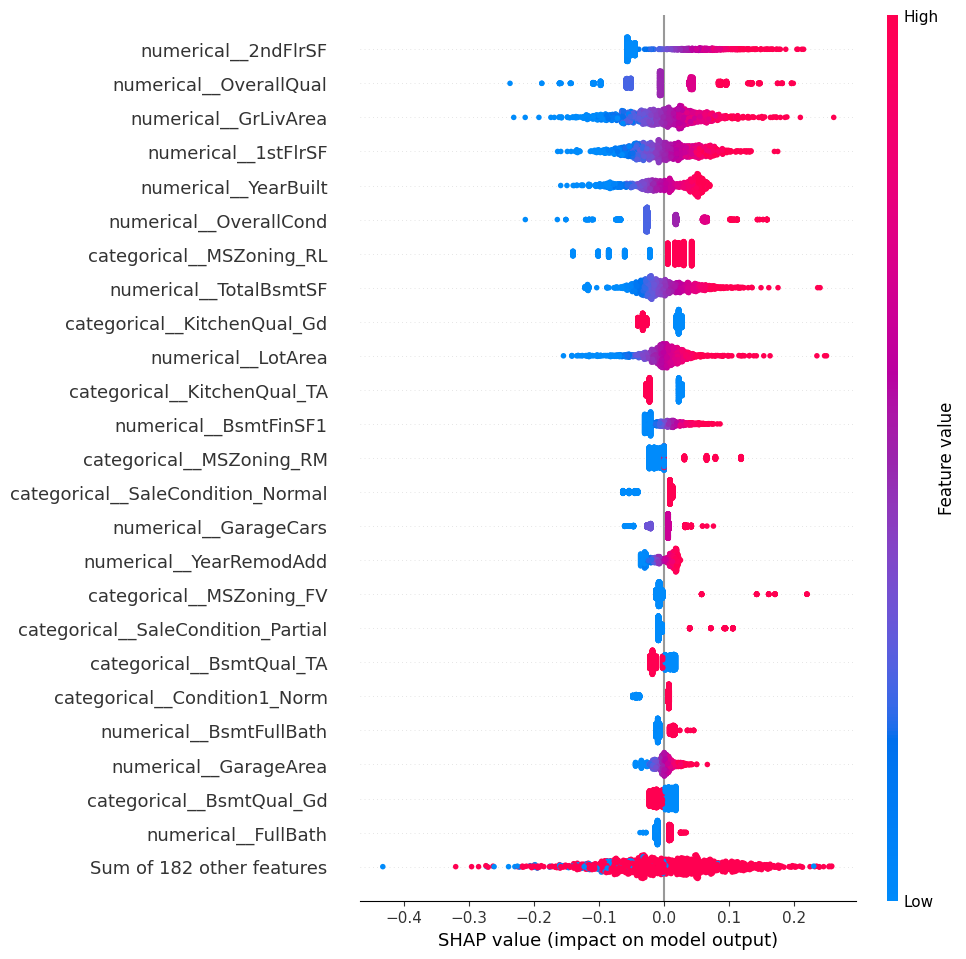

In [18]:
import warnings
from contextlib import redirect_stdout
from io import StringIO

import numpy as np
import pandas as pd
import shap

from src.train_functions import build_pipeline, cross_validate_standard

features = train_cv_df.drop(columns=['SalePrice'])

# assert config.general.experiment_name == '11_elastic_net_selected_log1p'
assert list(build_pipeline(config).named_steps) == ['selected_log1p', 'preprocessor', 'model']

oof_shap_parts = []
oof_transformed_parts = []

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Found unknown categories')

    # Повторяем CV, чтобы получить модели, обученные без соответствующих validation folds.
    with redirect_stdout(StringIO()):
        scores, fold_models, oof_predictions, fold_ids = cross_validate_standard(train_cv_df, 'SalePrice', config)

    for fold_index, pipe in enumerate(fold_models):
        train_mask = fold_ids != fold_index
        validation_mask = fold_ids == fold_index

        train_features = features.loc[train_mask]
        validation_features = features.loc[validation_mask]

        feature_pipeline = pipe[:-1]
        model = pipe.named_steps['model']

        train_transformed = feature_pipeline.transform(train_features)
        validation_transformed = feature_pipeline.transform(validation_features)
        feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

        # Каждый validation fold объясняется моделью, которая не обучалась на этих домах.
        masker = shap.maskers.Independent(train_transformed, max_samples=len(train_transformed))
        explainer = shap.LinearExplainer(model, masker)
        fold_explanation = explainer(validation_transformed)

        oof_shap_parts.append(
            pd.DataFrame(fold_explanation.values, index=validation_features.index, columns=feature_names)
        )
        oof_transformed_parts.append(
            pd.DataFrame(validation_transformed, index=validation_features.index, columns=feature_names)
        )

oof_shap_df = pd.concat(oof_shap_parts).reindex(features.index).fillna(0)
oof_transformed_df = pd.concat(oof_transformed_parts).reindex(features.index).fillna(0)

assert oof_shap_df.shape == oof_transformed_df.shape
assert len(oof_shap_df) == len(train_cv_df)
assert np.isfinite(oof_shap_df.to_numpy()).all()

shap_encoded_importance_df = (
    oof_shap_df.abs()
    .mean()
    .sort_values(ascending=False)
    .rename('mean_abs_shap')
    .rename_axis('feature')
    .reset_index()
)

display(shap_encoded_importance_df.head(20))

oof_explanation = shap.Explanation(
    values=oof_shap_df.to_numpy(),
    data=oof_transformed_df.to_numpy(),
    feature_names=oof_shap_df.columns.tolist(),
)

shap.plots.beeswarm(oof_explanation, max_display=25)

,feature,mean_abs_shap
0,2ndFlrSF,0.058973
1,OverallQual,0.052209
2,GrLivArea,0.047951
3,1stFlrSF,0.041683
4,YearBuilt,0.040508
5,OverallCond,0.039561
6,TotalBsmtSF,0.035063
7,LotArea,0.025971
8,BsmtFinSF1,0.020324
9,Neighborhood,0.017442


,feature,mean_abs_shap
41,BsmtCond,0.002715
42,LotFrontage,0.002578
43,BsmtFinSF2,0.002489
44,GarageFinish,0.002193
45,OpenPorchSF,0.001912
46,MoSold,0.001761
47,GarageCond,0.001740
48,LotShape,0.001713
49,BsmtFinType2,0.001400
50,PoolArea,0.001157


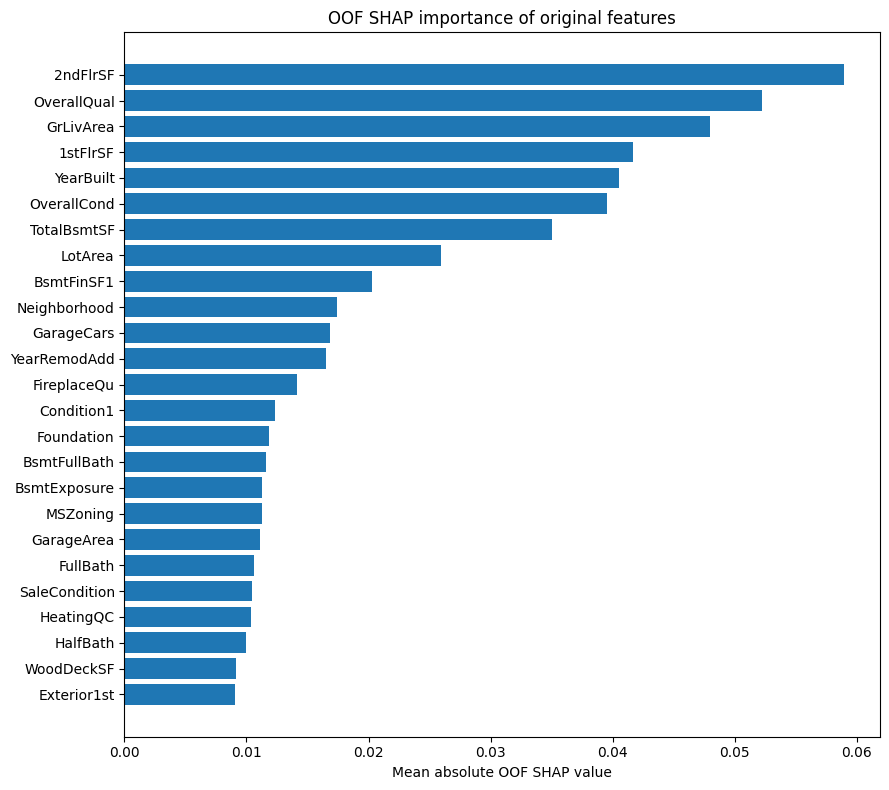

In [19]:
# Объединяем SHAP-вклады закодированных колонок до уровня исходных features.
raw_features = train_cv_df.drop(columns=['SalePrice', 'Id'], errors='ignore')
categorical_features = sorted(raw_features.select_dtypes(exclude=np.number).columns, key=len, reverse=True)

def get_original_feature(encoded_feature):
    '''Return the original feature name for an encoded feature.'''
    if encoded_feature.startswith('numerical__'):
        return encoded_feature.removeprefix('numerical__')

    encoded_name = encoded_feature.removeprefix('categorical__')
    for feature in categorical_features:
        if encoded_name == feature or encoded_name.startswith(f'{feature}_'):
            return feature

    raise ValueError(f'Original feature was not found: {encoded_feature}')

feature_map = pd.Series(
    {feature: get_original_feature(feature) for feature in oof_shap_df.columns},
    name='original_feature',
)

original_oof_shap_df = oof_shap_df.T.groupby(feature_map).sum().T
original_shap_importance_df = (
    original_oof_shap_df.abs().mean()
    .sort_values(ascending=False)
    .rename_axis('feature')
    .reset_index(name='mean_abs_shap')
)

display(original_shap_importance_df.head(25))
display(original_shap_importance_df.tail(20))

top_original_features = original_shap_importance_df.head(25).sort_values('mean_abs_shap')

plt.figure(figsize=(9, 8))
plt.barh(top_original_features['feature'], top_original_features['mean_abs_shap'])
plt.xlabel('Mean absolute OOF SHAP value')
plt.ylabel('')
plt.title('OOF SHAP importance of original features')
plt.tight_layout()
plt.show()

In [20]:
# Проверяем полноту сопоставления и сохранение суммарного SHAP-вклада.
mapped_features = set(feature_map)
expected_features = set(raw_features.columns)

# assert len(original_shap_importance_df) == raw_features.shape[1]
# assert mapped_features == expected_features
np.testing.assert_allclose(
    oof_shap_df.sum(axis=1),
    original_oof_shap_df.sum(axis=1),
    rtol=1e-10,
    atol=1e-10,
)

print(f'Encoded features: {oof_shap_df.shape[1]}')
print(f'Original features: {original_oof_shap_df.shape[1]}')
print('SHAP aggregation check passed.')

Encoded features: 206
Original features: 61
SHAP aggregation check passed.


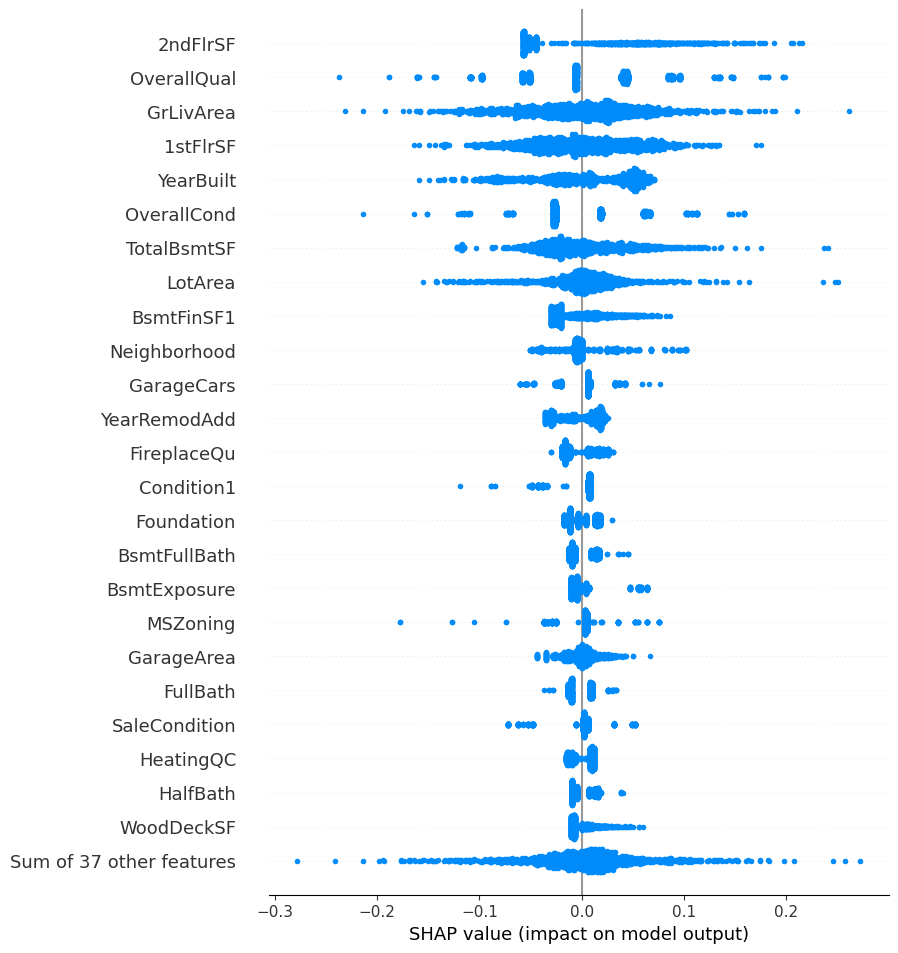

In [21]:
original_oof_explanation = shap.Explanation(
    values=original_oof_shap_df.to_numpy(),
    feature_names=original_oof_shap_df.columns.tolist(),
    # data=oof_transformed_df.to_numpy(),
)


shap.plots.beeswarm(original_oof_explanation, max_display=25)

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


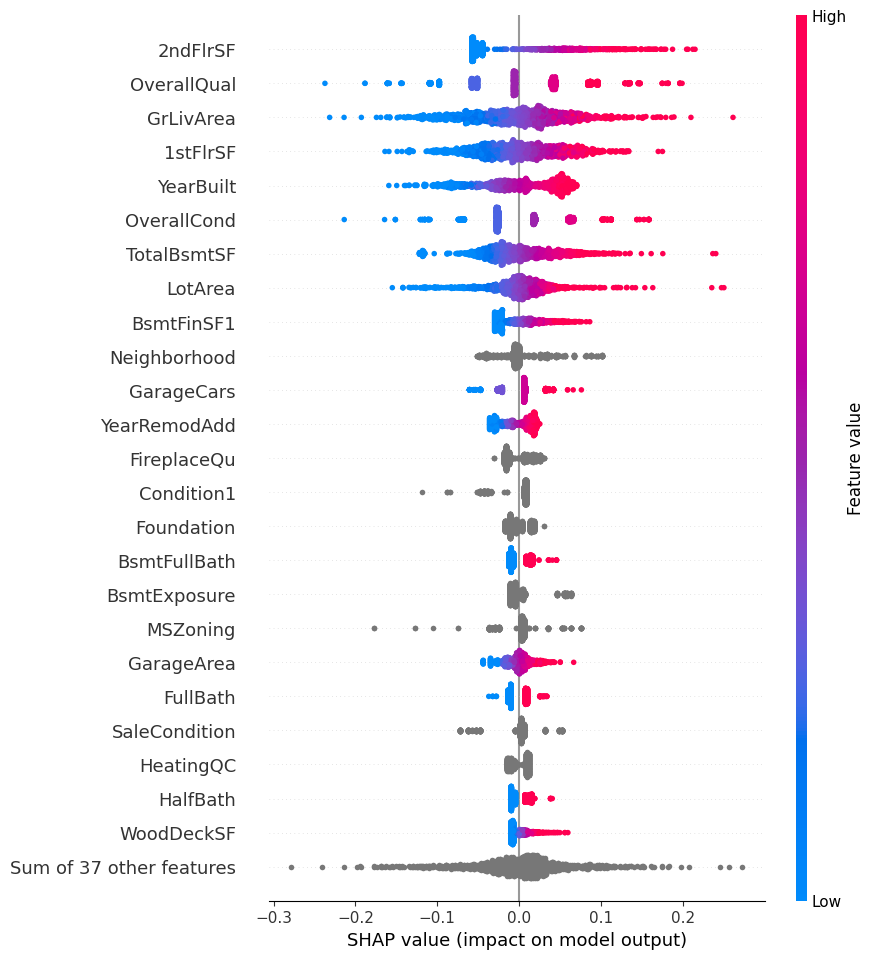

In [22]:
# Подготавливаем исходные числовые значения для окрашивания точек.
original_feature_names = original_oof_shap_df.columns.tolist()

assert original_oof_shap_df.index.isin(raw_features.index).all()

original_plot_data = raw_features.loc[
    original_oof_shap_df.index,
    original_feature_names,
].copy()

for feature in original_feature_names:
    if pd.api.types.is_numeric_dtype(original_plot_data[feature]):
        original_plot_data[feature] = original_plot_data[feature].fillna(
            original_plot_data[feature].median()
        )
    else:
        original_plot_data[feature] = np.nan

original_oof_explanation = shap.Explanation(
    values=original_oof_shap_df.to_numpy(),
    data=original_plot_data.to_numpy(dtype=float),
    feature_names=original_feature_names,
)

shap.plots.beeswarm(original_oof_explanation, max_display=25)

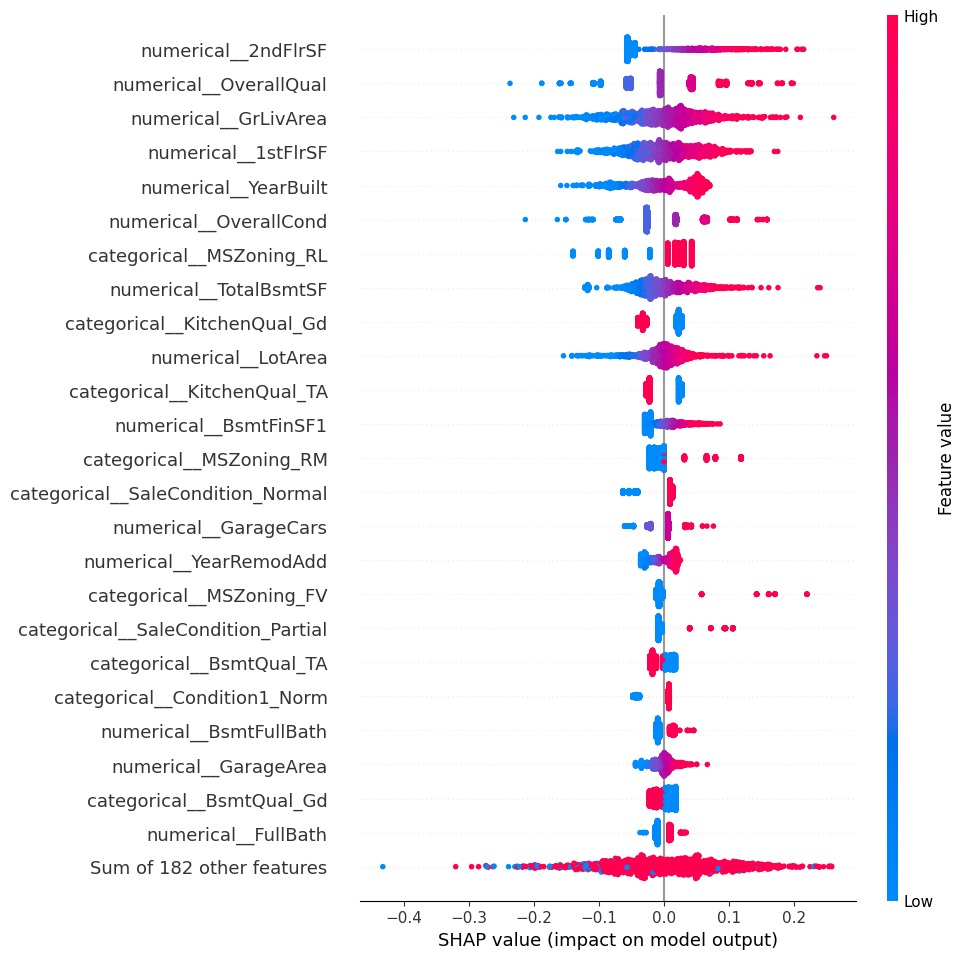

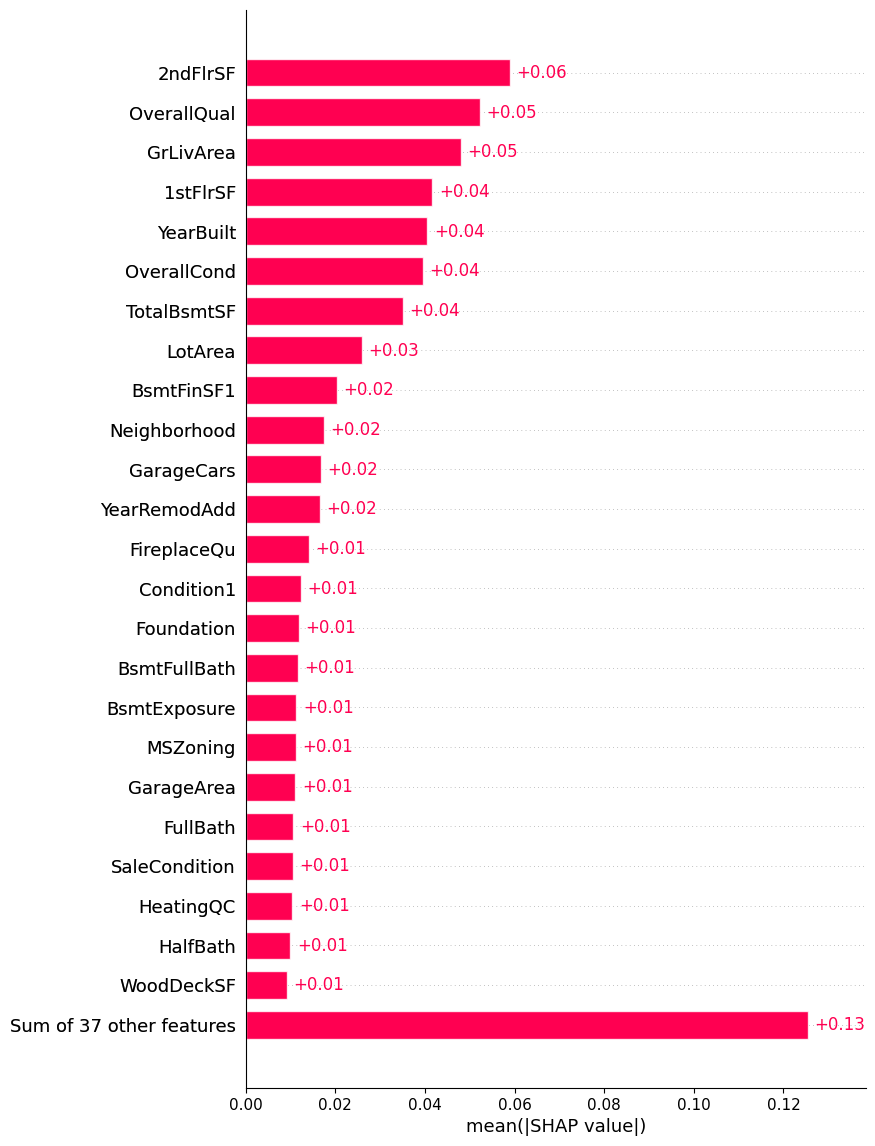

In [23]:
# Детальное направление влияния закодированных признаков.
shap.plots.beeswarm(oof_explanation, max_display=25)

# Общая важность исходных features.
shap.plots.bar(original_oof_explanation, max_display=25)

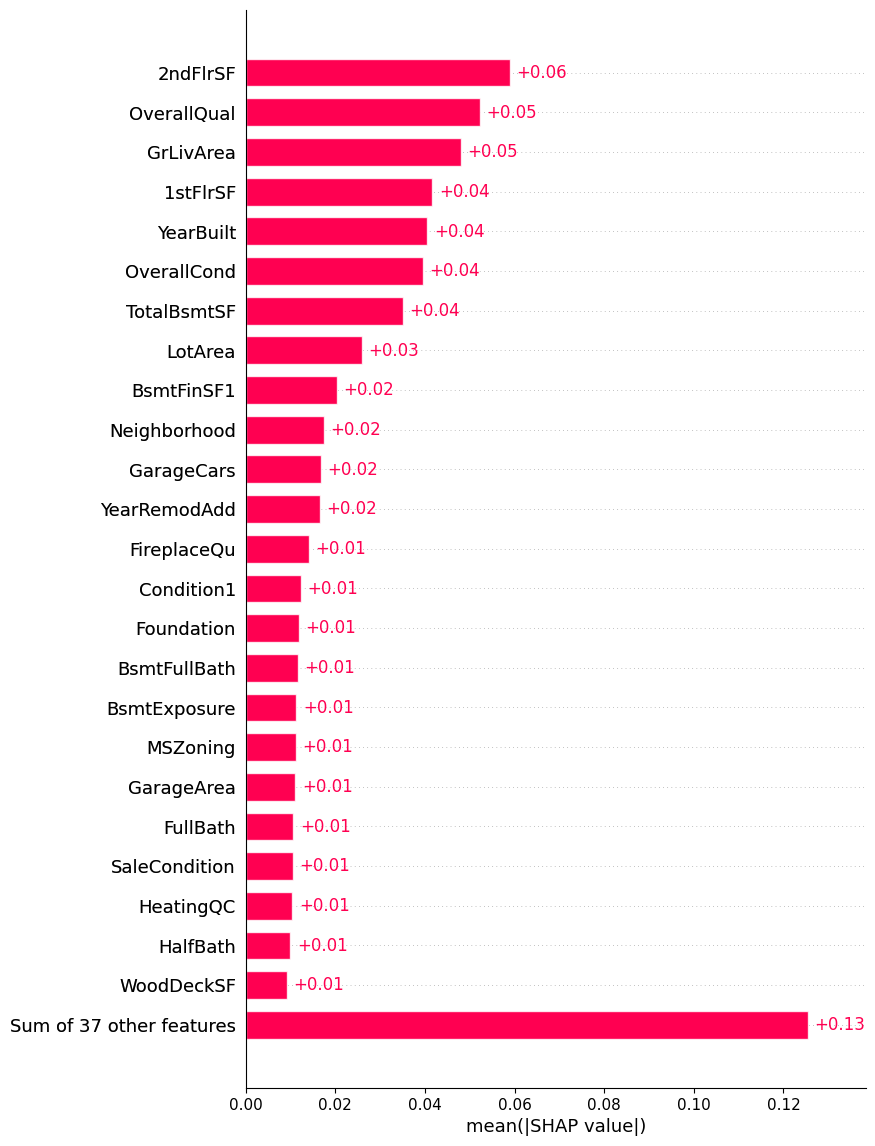

c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


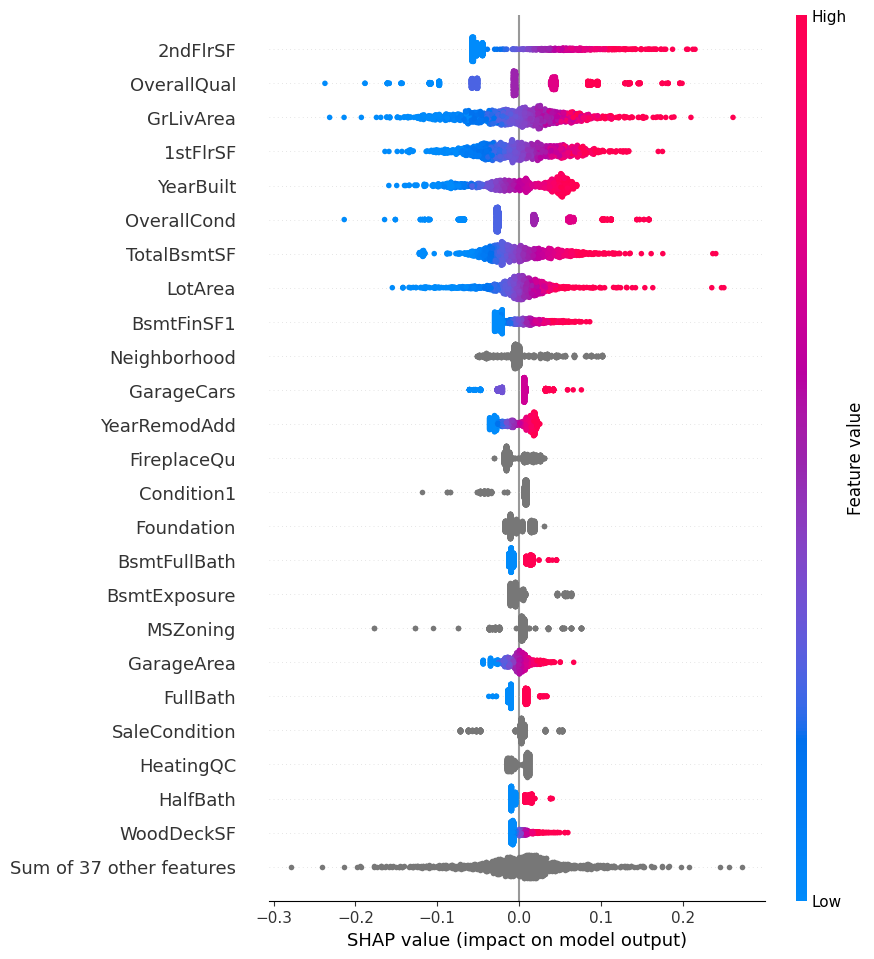

,feature,mean_abs_shap
0,2ndFlrSF,0.058973
1,OverallQual,0.052209
2,GrLivArea,0.047951
3,1stFlrSF,0.041683
4,YearBuilt,0.040508
...,...,...
56,LandContour,0.000554
57,LandSlope,0.000424
58,3SsnPorch,0.000293
59,MiscVal,0.000285


In [24]:
# Глобальный рейтинг исходных features.
shap.plots.bar(original_oof_explanation, max_display=25)

# Направление и распределение влияния исходных features.
shap.plots.beeswarm(original_oof_explanation, max_display=25)

# Полный рейтинг для подготовки feature selection.
display(original_shap_importance_df)

In [25]:
from pathlib import Path

shap_output_dir = Path('outputs/shap')
shap_output_dir.mkdir(parents=True, exist_ok=True)

baseline_shap_df = original_shap_importance_df.copy()
baseline_shap_df.insert(0, 'rank', np.arange(1, len(baseline_shap_df) + 1))
baseline_shap_df.to_csv(
    shap_output_dir / '29_elastic_net_return_garage_condition_shap.csv',
    index=False,
)

display(baseline_shap_df)

,rank,feature,mean_abs_shap
0,1,2ndFlrSF,0.058973
1,2,OverallQual,0.052209
2,3,GrLivArea,0.047951
3,4,1stFlrSF,0.041683
4,5,YearBuilt,0.040508
...,...,...,...
56,57,LandContour,0.000554
57,58,LandSlope,0.000424
58,59,3SsnPorch,0.000293
59,60,MiscVal,0.000285


## Проверка трансформаера лог по фичам

In [7]:
from src.feature_engineering import LOG1P_FEATURES, SelectedLog1pTransformer
from src.train_functions import build_pipeline

features_sample = train_cv_df.drop(columns=['SalePrice']).iloc[:100].copy()

log1p_transformer = SelectedLog1pTransformer()
transformed_sample = log1p_transformer.fit_transform(features_sample)

# Проверяем правильность преобразования выбранных features.
for feature in LOG1P_FEATURES:
    assert np.allclose(
        transformed_sample[feature],
        np.log1p(features_sample[feature]),
        equal_nan=True,
    )

# Остальные исходные features не должны измениться.
untouched_features = features_sample.columns.difference(LOG1P_FEATURES)
pd.testing.assert_frame_equal(
    transformed_sample[untouched_features],
    features_sample[untouched_features],
)

pipe = build_pipeline(config)

assert list(pipe.named_steps) == ['selected_log1p', 'preprocessor', 'model']

display(pd.concat(
    [
        features_sample[list(LOG1P_FEATURES)].head().add_suffix('_before'),
        transformed_sample[list(LOG1P_FEATURES)].head().add_suffix('_after'),
    ],
    axis=1,
))

pipe

,LotArea_before,LotFrontage_before,1stFlrSF_before,GrLivArea_before,LotArea_after,LotFrontage_after,1stFlrSF_after,GrLivArea_after
726,21695,NaN,1680,1680,9.984883,NaN,7.427144,7.427144
240,9000,75.0,1566,1566,9.105091,4.330733,7.356918,7.356918
94,9337,69.0,905,1786,9.141847,4.248495,6.809039,7.488294
1407,8780,NaN,833,833,9.080346,NaN,6.726233,6.726233
1416,11340,60.0,1246,2290,9.336180,4.110874,7.128496,7.736744


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('selected_log1p', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('structural_missing', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transforme

## ElasticNet preprocessing checks

In [7]:
import warnings
from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO
from itertools import product

import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import root_mean_squared_error

from src.data import load_data, split_train_holdout
from src.train_functions import cross_validate_standard


warnings.filterwarnings('ignore', message='Found unknown categories in columns.*', category=UserWarning)

train_df, _ = load_data(config)
train_cv_df, _ = split_train_holdout(train_df, config)
labels_log = np.log(train_cv_df['SalePrice'])

elastic_alphas = [0.00035, 0.00040, 0.00045, 0.00050, 0.00060, 0.00070, 0.00080]
l1_ratios = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
elastic_results = []

for alpha, l1_ratio in product(elastic_alphas, l1_ratios):
    trial_config = deepcopy(config)
    trial_config.model.models.elastic_net.alpha = alpha
    trial_config.model.models.elastic_net.l1_ratio = l1_ratio

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter('always', ConvergenceWarning)

        # Скрываем промежуточный вывод 42 × 5 фолдов.
        with redirect_stdout(StringIO()):
            scores, fold_models, oof_predictions, _ = cross_validate_standard(train_cv_df, 'SalePrice', trial_config)

    nonzero_counts = [np.count_nonzero(pipe.named_steps['model'].coef_) for pipe in fold_models]
    convergence_warnings = sum(issubclass(warning.category, ConvergenceWarning) for warning in caught_warnings)

    elastic_results.append({
        'alpha': alpha,
        'l1_ratio': l1_ratio,
        'mean_cv_rmse': np.mean(scores),
        'cv_std': np.std(scores),
        'oof_rmse': root_mean_squared_error(labels_log, oof_predictions),
        'mean_nonzero': np.mean(nonzero_counts),
        'convergence_warnings': convergence_warnings,
    })

elastic_results_df = pd.DataFrame(elastic_results).sort_values('mean_cv_rmse').reset_index(drop=True)

display(
    elastic_results_df.head(15).style.format({
        'alpha': '{:.5f}',
        'l1_ratio': '{:.2f}',
        'mean_cv_rmse': '{:.5f}',
        'cv_std': '{:.5f}',
        'oof_rmse': '{:.5f}',
        'mean_nonzero': '{:.1f}',
    })
)

Removed EDA outliers: [524, 1299] (1168 -> 1166)


,alpha,l1_ratio,mean_cv_rmse,cv_std,oof_rmse,mean_nonzero,convergence_warnings
0,0.00035,0.70,0.11135,0.01044,0.11183,143.4,0
1,0.00035,0.75,0.11136,0.01045,0.11183,140.0,0
2,0.00035,0.65,0.11138,0.01044,0.11185,147.8,0
3,0.00035,0.80,0.11138,0.01045,0.11186,137.6,0
4,0.00035,0.60,0.11140,0.01044,0.11188,152.0,0
5,0.00040,0.65,0.11141,0.01040,0.11188,140.6,0
6,0.00040,0.60,0.11141,0.01040,0.11189,144.8,0
7,0.00040,0.70,0.11144,0.01041,0.11191,137.6,0
8,0.00035,0.85,0.11145,0.01043,0.11193,134.6,0
9,0.00045,0.60,0.11148,0.01037,0.11195,140.0,0


## Lasso Regression preprocessing checks

In [9]:
from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

from src.train_functions import cross_validate_standard


selection_config = deepcopy(config)
selection_config.model.active = 'lasso'
selection_config.model.models.lasso.alpha = 0.00025

with redirect_stdout(StringIO()):
    _, fold_models, _, _ = cross_validate_standard(train_cv_df, 'SalePrice', selection_config)

fold_coefficients = []

for fold, pipe in enumerate(fold_models, start=1):
    feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
    coefficients = pipe.named_steps['model'].coef_
    fold_coefficients.append(pd.Series(coefficients, index=feature_names, name=f'fold_{fold}'))

coefficients_by_fold = pd.concat(fold_coefficients, axis=1)
present_by_fold = coefficients_by_fold.notna()
selected_by_fold = coefficients_by_fold.ne(0) & present_by_fold

In [10]:
encoded_summary = pd.DataFrame({
    'present_folds': present_by_fold.sum(axis=1),
    'nonzero_folds': selected_by_fold.sum(axis=1),
    'mean_abs_coefficient': coefficients_by_fold.abs().mean(axis=1),
})

encoded_summary['selection_rate'] = encoded_summary['nonzero_folds'] / encoded_summary['present_folds']
encoded_summary['status'] = np.select(
    [
        encoded_summary['nonzero_folds'].eq(0),
        encoded_summary['nonzero_folds'].eq(encoded_summary['present_folds']),
    ],
    ['always_zero', 'stable'],
    default='unstable',
)

encoded_summary = encoded_summary.rename_axis('feature').reset_index()

In [11]:
def extract_original_feature(encoded_name):
    '''Extract the original feature name from an encoded feature name.'''

    transformer, feature_name = encoded_name.split('__', maxsplit=1)

    if transformer == 'categorical':
        return feature_name.split('_', maxsplit=1)[0]

    return feature_name


original_names = pd.Series(
    [extract_original_feature(name) for name in coefficients_by_fold.index],
    index=coefficients_by_fold.index,
)

original_selected = selected_by_fold.groupby(original_names).any()
original_present = present_by_fold.groupby(original_names).any()

original_summary = pd.DataFrame({
    'encoded_features': original_names.value_counts(),
    'present_folds': original_present.sum(axis=1),
    'nonzero_folds': original_selected.sum(axis=1),
})

original_summary['selection_rate'] = original_summary['nonzero_folds'] / original_summary['present_folds']
original_summary['status'] = np.select(
    [
        original_summary['nonzero_folds'].eq(0),
        original_summary['nonzero_folds'].eq(original_summary['present_folds']),
    ],
    ['always_zero', 'stable'],
    default='unstable',
)

original_summary = original_summary.rename_axis('feature').reset_index()

In [12]:
display(original_summary['status'].value_counts())
display(original_summary.query("status == 'always_zero'").sort_values('feature'))
display(original_summary.query("status == 'unstable'").sort_values('selection_rate'))

status
stable         62
unstable       13
always_zero     4
Name: count, dtype: int64

,feature,encoded_features,present_folds,nonzero_folds,selection_rate,status
0,1stFlrSF,1,5,0,0.0,always_zero
15,BsmtUnfSF,1,5,0,0.0,always_zero
18,Condition2,7,5,0,0.0,always_zero
74,Utilities,1,4,0,0.0,always_zero


,feature,encoded_features,present_folds,nonzero_folds,selection_rate,status
1,2ndFlrSF,1,5,2,0.4,unstable
3,Alley,2,5,3,0.6,unstable
54,MasVnrArea,1,5,3,0.6,unstable
37,GarageYrBlt,1,5,3,0.6,unstable
71,Street,1,5,3,0.6,unstable
65,PoolQC,3,5,3,0.6,unstable
27,Fireplaces,1,5,4,0.8,unstable
4,BedroomAbvGr,1,5,4,0.8,unstable
51,LowQualFinSF,1,5,4,0.8,unstable
40,Heating,5,5,4,0.8,unstable


In [8]:
import warnings
from contextlib import redirect_stdout
from copy import deepcopy
from io import StringIO

import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import root_mean_squared_error

from src.data import load_data, split_train_holdout
from src.train_functions import cross_validate_standard


warnings.filterwarnings('ignore', message='Found unknown categories in columns.*', category=UserWarning)

train_df, _ = load_data(config)
train_cv_df, _ = split_train_holdout(train_df, config)

lasso_alphas = [
    0.00015,
    0.00020,
    0.00025,
    0.00030,
    0.00040,
    0.00050,
    0.00060,
    0.00075,
    0.00090,
]
labels_log = np.log(train_cv_df['SalePrice'])
alpha_results = []

for alpha in lasso_alphas:
    trial_config = deepcopy(config)
    trial_config.model.models.lasso.alpha = alpha

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter('always', ConvergenceWarning)

        # Скрываем вывод каждого фолда, чтобы таблица результатов оставалась читаемой.
        with redirect_stdout(StringIO()):
            scores, fold_models, oof_predictions, _ = cross_validate_standard(train_cv_df, 'SalePrice', trial_config)

    nonzero_counts = [np.count_nonzero(pipe.named_steps['model'].coef_) for pipe in fold_models]
    convergence_warnings = sum(issubclass(warning.category, ConvergenceWarning) for warning in caught_warnings)

    alpha_results.append({
        'alpha': alpha,
        'mean_cv_rmse': np.mean(scores),
        'cv_std': np.std(scores),
        'oof_rmse': root_mean_squared_error(labels_log, oof_predictions),
        'mean_nonzero': np.mean(nonzero_counts),
        'convergence_warnings': convergence_warnings,
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values('mean_cv_rmse').reset_index(drop=True)

display(
    alpha_results_df.style.format({
        'alpha': '{:.5f}',
        'mean_cv_rmse': '{:.5f}',
        'cv_std': '{:.5f}',
        'oof_rmse': '{:.5f}',
        'mean_nonzero': '{:.1f}',
    })
)

Removed EDA outliers: [524, 1299] (1168 -> 1166)


,alpha,mean_cv_rmse,cv_std,oof_rmse,mean_nonzero,convergence_warnings
0,0.00025,0.11381,0.01146,0.11437,144.8,0
1,0.00030,0.11383,0.01154,0.11440,133.0,0
2,0.00040,0.11392,0.01074,0.11441,119.6,0
3,0.00020,0.11405,0.01131,0.11459,155.0,0
4,0.00050,0.11425,0.01038,0.11471,110.6,0
5,0.00060,0.11446,0.01028,0.11491,101.0,0
6,0.00075,0.11480,0.00993,0.11522,91.2,0
7,0.00015,0.11497,0.01120,0.11550,170.8,0
8,0.00090,0.11537,0.00959,0.11576,84.6,0


## Ridge Regression preprocessing checks

In [8]:
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd

from sklearn.metrics import root_mean_squared_error

from src.data import load_data, split_train_holdout
from src.train_functions import cross_validate_standard


warnings.filterwarnings(
    'ignore',
    message='Found unknown categories in columns.*',
    category=UserWarning,
)

train_df, _ = load_data(config)
train_cv_df, _ = split_train_holdout(train_df, config)

ridge_alphas = [5.0, 7.5, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]
labels_log = np.log(train_cv_df['SalePrice'])
alpha_results = []

for alpha in ridge_alphas:
    trial_config = deepcopy(config)
    trial_config.model.models.ridge.alpha = alpha

    scores, _, oof_predictions, _ = cross_validate_standard(train_cv_df, 'SalePrice', trial_config)
    oof_rmse = root_mean_squared_error(labels_log, oof_predictions)

    alpha_results.append({
        'alpha': alpha,
        'mean_cv_rmse': np.mean(scores),
        'cv_std': np.std(scores),
        'oof_rmse': oof_rmse,
    })

alpha_results_df = pd.DataFrame(alpha_results).sort_values('mean_cv_rmse').reset_index(drop=True)
alpha_results_df

Removed EDA outliers: [524, 1299] (1168 -> 1166)
Fold 1: RMSE(log) = 0.10059
Fold 2: RMSE(log) = 0.12557
Fold 3: RMSE(log) = 0.12899
Fold 4: RMSE(log) = 0.12003
Fold 5: RMSE(log) = 0.10858
Fold 1: RMSE(log) = 0.10073
Fold 2: RMSE(log) = 0.12432
Fold 3: RMSE(log) = 0.12842
Fold 4: RMSE(log) = 0.11966
Fold 5: RMSE(log) = 0.10803
Fold 1: RMSE(log) = 0.10093
Fold 2: RMSE(log) = 0.12361
Fold 3: RMSE(log) = 0.12800
Fold 4: RMSE(log) = 0.11943
Fold 5: RMSE(log) = 0.10782
Fold 1: RMSE(log) = 0.10143
Fold 2: RMSE(log) = 0.12287
Fold 3: RMSE(log) = 0.12745
Fold 4: RMSE(log) = 0.11919
Fold 5: RMSE(log) = 0.10785
Fold 1: RMSE(log) = 0.10195
Fold 2: RMSE(log) = 0.12256
Fold 3: RMSE(log) = 0.12714
Fold 4: RMSE(log) = 0.11911
Fold 5: RMSE(log) = 0.10814
Fold 1: RMSE(log) = 0.10246
Fold 2: RMSE(log) = 0.12245
Fold 3: RMSE(log) = 0.12699
Fold 4: RMSE(log) = 0.11911
Fold 5: RMSE(log) = 0.10853
Fold 1: RMSE(log) = 0.10295
Fold 2: RMSE(log) = 0.12244
Fold 3: RMSE(log) = 0.12694
Fold 4: RMSE(log) = 0.11915

,alpha,mean_cv_rmse,cv_std,oof_rmse
0,15.0,0.115757,0.009663,0.116148
1,20.0,0.115781,0.009336,0.116145
2,25.0,0.115907,0.009069,0.116250
3,10.0,0.115958,0.010074,0.116382
4,30.0,0.116084,0.008846,0.116410
5,7.5,0.116234,0.010329,0.116679
6,40.0,0.116503,0.008493,0.116802
7,5.0,0.116751,0.010641,0.117222
8,50.0,0.116946,0.008227,0.117225


In [9]:
pipe = build_pipeline(config)

In [10]:
from sklearn.linear_model import Ridge

model = pipe.named_steps['model']

assert isinstance(model, Ridge)
assert model.alpha == config.model.models.ridge.alpha
assert model.fit_intercept == config.model.models.ridge.fit_intercept

print(model)

Ridge()


In [11]:
pipe.fit(features_sample, labels_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('structural_missing', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', '

## Linear Regression preprocessing checks

In [6]:
from src.train_functions import build_pipeline

pipe = build_pipeline(config)

features_sample = X.iloc[:100]
labels_sample = y.iloc[:100]

# Проверяем обучение и получение предсказаний на небольшой части данных.
pipe.fit(features_sample, labels_sample)

predictions_log = pipe.predict(X.iloc[100:105])
predictions_dollars = np.exp(predictions_log)

assert predictions_log.shape == (5,)
assert np.isfinite(predictions_log).all()
assert (predictions_dollars > 0).all()

# Проверяем размер матрицы после полного preprocessing.
preprocessor = pipe.named_steps['preprocessor']
transformed_sample = preprocessor.transform(features_sample)
feature_names = preprocessor.get_feature_names_out()

assert transformed_sample.shape[0] == len(features_sample)
assert transformed_sample.shape[1] == len(feature_names)
assert np.isfinite(transformed_sample).all()

print('Исходная выборка:', features_sample.shape)
print('После preprocessing:', transformed_sample.shape)

pd.DataFrame({
    'actual_price': train_df['SalePrice'].iloc[100:105].to_numpy(),
    'predicted_price': predictions_dollars,
})

Исходная выборка: (100, 79)
После preprocessing: (100, 200)


c:\Users\aukha\anaconda3\envs\house_prices\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [43] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,actual_price,predicted_price
0,205000,215297.213202
1,178000,182789.949525
2,118964,111315.548318
3,198900,175256.806148
4,169500,136940.014755


In [7]:
structural_transformer = preprocessor.named_steps['structural_missing']
structural_features = structural_transformer.transform(X)

no_pool = X['PoolArea'].eq(0)
no_fireplace = X['Fireplaces'].eq(0)
no_garage = X['GarageCars'].eq(0) & X['GarageArea'].eq(0)
no_basement = X['TotalBsmtSF'].eq(0)

garage_features = [
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
]

basement_features = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
]

# Проверяем заполнение categorical structural missing.
assert structural_features.loc[no_pool, 'PoolQC'].eq('NoPool').all()
assert structural_features.loc[no_fireplace, 'FireplaceQu'].eq('NoFireplace').all()
assert structural_features.loc[no_garage, garage_features].eq('NoGarage').all().all()
assert structural_features.loc[no_basement, basement_features].eq('NoBasement').all().all()

assert structural_features['Alley'].notna().all()
assert structural_features['Fence'].notna().all()
assert structural_features['MiscFeature'].notna().all()

# Настоящий пропуск BsmtExposure при существующем подвале должен сохраниться.
unknown_basement_exposure = X['BsmtExposure'].isna() & X['TotalBsmtSF'].gt(0)

assert structural_features.loc[unknown_basement_exposure, 'BsmtExposure'].isna().all()

print('NoPool:', structural_features['PoolQC'].eq('NoPool').sum())
print('NoFireplace:', structural_features['FireplaceQu'].eq('NoFireplace').sum())
print('NoGarage:', structural_features['GarageType'].eq('NoGarage').sum())
print('NoBasement:', structural_features['BsmtQual'].eq('NoBasement').sum())
print('Настоящих пропусков BsmtExposure:', unknown_basement_exposure.sum())

NoPool: 1453
NoFireplace: 690
NoGarage: 81
NoBasement: 37
Настоящих пропусков BsmtExposure: 1


In [ ]:
def format_dollars(value):
    return f'${value:,.2f}'

oof_analysis = train_cv_df[['Id', 'SalePrice']].copy()

oof_analysis['fold'] = fold_ids + 1
oof_analysis['actual_log'] = np.log(oof_analysis['SalePrice'])
oof_analysis['prediction_log'] = oof_predictions
oof_analysis['prediction_price'] = np.exp(oof_predictions)

oof_analysis['error_log'] = (
    oof_analysis['prediction_log']
    - oof_analysis['actual_log']
)

oof_analysis['abs_error_log'] = oof_analysis['error_log'].abs()
oof_analysis['squared_error_log'] = oof_analysis['error_log'] ** 2

fold_error_summary = (
    oof_analysis
    .groupby('fold')
    .agg(
        samples=('Id', 'size'),
        mae_log=('abs_error_log', 'mean'),
        mean_squared_error_log=('squared_error_log', 'mean'),
        max_abs_error_log=('abs_error_log', 'max'),
    )
)

fold_error_summary['rmse_log'] = np.sqrt(
    fold_error_summary['mean_squared_error_log']
)

fold_error_summary = fold_error_summary[
    [
        'samples',
        'rmse_log',
        'mae_log',
        'max_abs_error_log',
    ]
]

largest_errors = (
    oof_analysis
    .sort_values(
        ['fold', 'abs_error_log'],
        ascending=[True, False],
    )
    .groupby('fold')
    .head(5)
)

display(fold_error_summary.round(5))

largest_errors_display = largest_errors[
    [
        'fold',
        'Id',
        'SalePrice',
        'prediction_price',
        'error_log',
        'abs_error_log',
    ]
]

display(
    largest_errors_display.style.format({
        'SalePrice': format_dollars,
        'prediction_price': format_dollars,
        'error_log': '{:.5f}',
        'abs_error_log': '{:.5f}',
    })
)

influential_houses = oof_analysis[
    oof_analysis['Id'].isin([524, 1299])
]

display(
    influential_houses.style.format({
        'SalePrice': format_dollars,
        'prediction_price': format_dollars,
        'actual_log': '{:.5f}',
        'prediction_log': '{:.5f}',
        'error_log': '{:.5f}',
        'abs_error_log': '{:.5f}',
        'squared_error_log': '{:.5f}',
    })
)

,samples,rmse_log,mae_log,max_abs_error_log
fold,,,,
1,234,0.13292,0.08972,0.98118
2,234,0.25711,0.11673,2.72961
3,234,0.15815,0.08931,1.55727
4,233,0.15531,0.09609,0.96559
5,233,0.22473,0.11098,2.47731


,fold,Id,SalePrice,prediction_price,error_log,abs_error_log
346,1,347,"$151,500.00","$56,792.58",-0.98118,0.98118
529,1,530,"$200,624.00","$316,186.05",0.45490,0.45490
581,1,582,"$253,293.00","$383,718.56",0.41536,0.41536
1270,1,1271,"$260,000.00","$177,685.22",-0.38067,0.38067
313,1,314,"$375,000.00","$534,139.76",0.35373,0.35373
1275,2,1276,"$137,000.00","$8,938.54",-2.72961,2.72961
825,2,826,"$385,000.00","$74,944.27",-1.63650,1.63650
88,2,89,"$85,000.00","$33,234.95",-0.93905,0.93905
632,2,633,"$82,500.00","$174,006.72",0.74630,0.74630
30,2,31,"$40,000.00","$68,454.01",0.53728,0.53728


,Id,SalePrice,fold,actual_log,prediction_log,prediction_price,error_log,abs_error_log,squared_error_log
523,524,"$184,750.00",3,12.12676,13.68403,"$876,798.99",1.55727,1.55727,2.42510
1298,1299,"$160,000.00",5,11.98293,14.46024,"$1,905,475.72",2.47731,2.47731,6.13708


In [ ]:
for fold, pipe in enumerate(fold_models, start=1):
    preprocessor = pipe.named_steps['preprocessor']

    selected_columns = [
        column
        for name, transformer, columns in preprocessor.transformers_
        if name in ('numerical', 'categorical')
        for column in columns
    ]

    assert 'Id' not in selected_columns
    assert 'SalePrice' not in selected_columns
    assert len(selected_columns) == 79

    encoded_count = len(preprocessor.get_feature_names_out())
    print(f'Fold {fold}: исходных признаков — {len(selected_columns)}, после one-hot — {encoded_count}')

AttributeError: 'Pipeline' object has no attribute 'transformers_'

In [ ]:
from src.experiment_logging import save_oof_predictions

oof_df = save_oof_predictions(train_cv_df, oof_predictions, fold_ids, config)

assert len(oof_df) == len(train_cv_df)
assert oof_df['Id'].equals(train_cv_df['Id'])
assert np.isfinite(oof_df['prediction_price']).all()

columns = ['Id', 'SalePrice', 'prediction_price', 'error_price', 'abs_error_log']
oof_df.nlargest(10, 'abs_error_log')[columns]

OOF predictions saved: outputs\oof\1_baseline_RF.csv
OOF errors saved: outputs\oof\1_baseline_RF_errors.csv


,Id,SalePrice,prediction_price,error_price,abs_error_log
523,524,184750,528633.237557,343883.237557,1.051291
30,31,40000,96213.470662,56213.470662,0.877690
495,496,34900,82679.688823,47779.688823,0.862487
632,633,82500,192670.137286,110170.137286,0.848181
1298,1299,160000,367912.518981,207912.518981,0.832671
410,411,60000,125606.674511,65606.674511,0.738811
1349,1350,122000,254679.021093,132679.021093,0.735983
462,463,62383,128460.513438,66077.513438,0.722329
916,917,35311,71087.130609,35776.130609,0.699712
1324,1325,147000,285657.232952,138657.232952,0.664360


In [ ]:
from src.train_functions import predict_with_pipeline_ensemble, calculate_regression_metrics
from src.experiment_logging import print_regression_metrics

oof_metrics = calculate_regression_metrics(train_cv_df['SalePrice'], oof_predictions)
print_regression_metrics('OOF', oof_metrics)

features_holdout = holdout_df.drop(columns=['SalePrice'])
holdout_predictions_log = predict_with_pipeline_ensemble(features_holdout, fold_models)

holdout_metrics = calculate_regression_metrics(holdout_df['SalePrice'], holdout_predictions_log)
print_regression_metrics('Holdout', holdout_metrics)


OOF:
RMSE(log): 0.14762
MAE($):    18,324.75
MSE($²):   965,909,905.65
RMSE($):   31,079.09
R²:        0.84792
MAPE:      10.32%
SMAPE:     9.80%
WAPE:      10.04%

Holdout:
RMSE(log): 0.13891
MAE($):    17,035.45
MSE($²):   769,658,563.94
RMSE($):   27,742.72
R²:        0.87328
MAPE:      9.98%
SMAPE:     9.71%
WAPE:      9.78%


In [ ]:
from src.experiment_logging import save_holdout_predictions

holdout_predictions_df = save_holdout_predictions(holdout_df, holdout_predictions_log, config)

display(holdout_predictions_df.head())

Holdout predictions saved: outputs\holdout\1_baseline_RF.csv


,Id,SalePrice,actual_log,prediction_log,prediction_price,error_log,abs_error_log,error_price
1261,1262,128900,11.766792,11.804205,133813.915806,0.037413,0.037413,4913.915806
138,139,230000,12.345835,12.433006,250949.209656,0.087171,0.087171,20949.209656
578,579,146000,11.891362,12.006417,163802.511248,0.115055,0.115055,17802.511248
1125,1126,115000,11.652687,11.694981,119968.058935,0.042293,0.042293,4968.058935
1356,1357,110000,11.608236,11.682233,118448.428652,0.073997,0.073997,8448.428652


In [ ]:
from src.experiment_logging import save_submission

test_predictions_log = predict_with_pipeline_ensemble(test_df, fold_models)
submission_df = save_submission(test_df, test_predictions_log, config)

print('Submission shape:', submission_df.shape)
display(submission_df.head())

Submission saved: outputs\submissions\1_baseline_RF.csv
Submission shape: (1459, 2)


,Id,SalePrice
0,1461,127066.831830
1,1462,154145.209126
2,1463,178352.283953
3,1464,181434.217230
4,1465,191029.506057
